In [1]:
import pandas
import os

datafolder = "retraction-watch-data/"
csvfile = "retraction_watch.csv"

In [2]:
df = pandas.read_csv(os.path.join(datafolder, csvfile), encoding='iso-8859-1')

In [3]:
df.columns

Index(['Record ID', 'Title', 'Subject', 'Institution', 'Journal', 'Publisher',
       'Country', 'Author', 'URLS', 'ArticleType', 'RetractionDate',
       'RetractionDOI', 'RetractionPubMedID', 'OriginalPaperDate',
       'OriginalPaperDOI', 'OriginalPaperPubMedID', 'RetractionNature',
       'Reason', 'Paywalled', 'Notes', 'Unnamed: 20'],
      dtype='str')

In [4]:
df.head()

,Record ID,Title,Subject,Institution,Journal,Publisher,Country,Author,URLS,ArticleType,...,RetractionDOI,RetractionPubMedID,OriginalPaperDate,OriginalPaperDOI,OriginalPaperPubMedID,RetractionNature,Reason,Paywalled,Notes,Unnamed: 20
0,72186.0,"Social, economic and environmental vulnerabili...",(B/T) Business - Economics;(BLS) Agriculture;(...,Institute of Agricultural Education and Extens...,Science of The Total Environment,Elsevier,Belgium;China;Czech Republic;Estonia;Iran;Neth...,Saeedeh Nazari Nooghabi;Hossein Azadi;Luuk Fle...,NaN,Research Article;,...,10.1016/j.scitotenv.2026.182004,42379914.0,11/10/2021 0:00,10.1016/j.scitotenv.2021.151519,34774624.0,Retraction,Concerns/Issues about Authorship/Affiliation;I...,No,"Saeedeh Nazari Nooghabi a, Hossein Azadi b c d...",NaN
1,72183.0,High-throughput screening of ancient forest pl...,(HSC) Medicine - Drug Design;(HSC) Medicine - ...,Henan Province International Collaboration Lab...,Environment International,Elsevier,China;Denmark;India;Malaysia;Norway;Taiwan,Yiyang Li;Nyuk Ling Ma;Huiling Chen;Jiateng Zh...,NaN,Research Article;,...,10.1016/j.envint.2023.108279,0.0,10/29/2023 0:00,10.1016/j.envint.2023.108279,37924601.0,Retraction,Compromised Peer Review;Objections by Author(s...,No,See also: https://pubpeer.com/publications/39A...,NaN
2,72181.0,Nitrogen transformation in slightly polluted s...,(BLS) Microbiology;(ENV) Ground/Surface Water;,Key Laboratory for Technology in Rural Water M...,Science of The Total Environment,Elsevier,China;South Korea;Sri Lanka;United States,Yinfeng Xia;Lifang Zhu;Nan Geng;Debao Lu;Cundo...,NaN,Research Article;,...,10.1016/j.scitotenv.2026.182090,42521574.0,3/18/2022 0:00,10.1016/j.scitotenv.2022.154623,35307444.0,Retraction,Compromised Peer Review;Investigation by Journ...,No,See also: https://pubpeer.com/publications/9DF...,NaN
3,72175.0,Porous carbon polyhedrons with exclusive Cu-Nx...,(PHY) Energy;(PHY) Materials Science;,State Key Laboratory of Marine Resource Utiliz...,International Journal of Hydrogen Energy,Elsevier,China,Yalin Liu;Peng Rao;Mingjun Zhong;Ruisong Li;Ji...,NaN,Research Article;,...,10.1016/j.ijhydene.2026.156515,0.0,6/30/2021 0:00,10.1016/j.ijhydene.2021.06.057,0.0,Retraction,Concerns/Issues about Authorship/Affiliation;I...,No,NaN,NaN
4,72174.0,The Existence of Solution for k-Dimensional Sy...,(PHY) Mathematics;,"Department of Mathematics, Faculty of Science,...",Mediterranean Journal of Mathematics,Springer - Nature Publishing Group,Iran,Mohammad Esmael Samei;Vahid Hedayati;Ghorban K...,NaN,Research Article;,...,10.1007/s00009-021-01922-2,0.0,1/11/2020 0:00,10.1007/s00009-019-1471-2,0.0,Retraction,Euphemisms for Plagiarism;Objections by Author...,No,NaN,NaN


In [5]:
df.dropna(subset=['RetractionDate', 'OriginalPaperDate'], inplace=True)

In [6]:
df['RetractionDate'] = pandas.to_datetime(df['RetractionDate'], errors='coerce', format='mixed')
df['OriginalPaperDate'] = pandas.to_datetime(df['OriginalPaperDate'], errors='coerce', format='mixed')

<Axes: xlabel='OriginalPaperDate', ylabel='RetractionDate'>

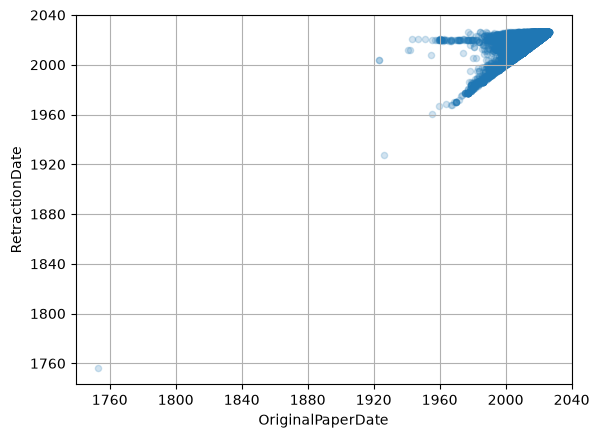

In [7]:
df.plot.scatter('OriginalPaperDate', 'RetractionDate', alpha=0.2, grid=True)

In [8]:
## This code adapted from Jonas Oppenlaender https://github.com/retractions/retractions.github.io/tree/master
import pandas as pd
import matplotlib.pyplot as plt

AXIS_FONTSIZE = 16
TICK_FONTSIZE = 12
LABEL_FONTSIZE = 14

PUBLISHERS = {
    'ACM': ['Association for Computing Machinery (ACM)'],
    'IEEE': ['IEEE: Institute of Electrical and Electronics Engineers'],
    'Elsevier': ['Elsevier', 'Elsevier - Cell Press'],
    'Springer Nature': ['Springer', 'Springer - Nature Publishing Group', 'Springer - Biomed Central (BMC)'],
    'Wiley': ['Wiley'],
    'Taylor & Francis': ['Taylor and Francis', 'Taylor and Francis - Dove Press'],
    'SAGE': ['SAGE Publications'],
    'Hindawi': ['Hindawi'],
    'IOS Press': ['IOS Press (bought by Sage November 2023)'],
    'PLoS': ['PLoS'],
}

PUBLISHER_COLORS = {    'ACM': 'blue',
    'IEEE': 'orange',
    'Elsevier': 'green',
    'Springer Nature': 'cyan',
    'Wiley': 'gold',
    'Taylor & Francis': 'purple',
    'SAGE': 'red',
    'Hindawi': 'brown',
    'IOS Press': 'salmon',
    'PLoS': 'grey',}

def plot_small_multiples(df, freq, log_scale, output_file, figsize=(20, 8)):
    """Plot a 2x4 grid of bar charts, one per publisher.

    Parameters
    ----------
    df : DataFrame with 'Publisher' and 'RetractionDate' columns.
    freq : 'M' for monthly, 'Q' for quarterly.
    log_scale : bool — use logarithmic y-axis.
    output_file : str — path for the saved PDF figure.
    figsize : tuple — overall figure size.
    """
    # Compute period counts per publisher and determine global date range
    period_counts = {}
    all_min, all_max = None, None
    for label, rw_names in PUBLISHERS.items():
        pub_df = df[df['Publisher'].isin(rw_names)]
        counts = pub_df['RetractionDate'].dt.to_period(freq).value_counts().sort_index()
        period_counts[label] = counts
        if len(counts) > 0:
            pmin, pmax = counts.index.min(), counts.index.max()
            all_min = pmin if all_min is None else min(all_min, pmin)
            all_max = pmax if all_max is None else max(all_max, pmax)

    # plot all x-values
    # full_range = pd.period_range(start=all_min, end=all_max, freq=freq)
    # instead, enforce start date of 1997 (ACM-DL launched October 1997)
    start_date = pd.Period('1997-01', freq=freq)
    # Ensure we don't cut off data if the max date is somehow older than 1997 (unlikely but safe)
    if all_max < start_date:
        print("Warning: Data ends before 1997 start date.")
        return
    # Create range from 1997 to the actual data end
    full_range = pd.period_range(start=start_date, end=all_max, freq=freq)


    # Reindex all publishers to the shared range
    for label in period_counts:
        period_counts[label] = period_counts[label].reindex(full_range, fill_value=0)

    # Calculate global max for BOTH linear and log
    global_ymax = max(s.max() for s in period_counts.values())

    ncols = 5
    nrows = 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 8), squeeze=False)

    for idx, (label, counts) in enumerate(period_counts.items()):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]
        color = PUBLISHER_COLORS[label]

        ax.bar(range(len(full_range)), counts.values, width=0.8, color=color, alpha=0.9)
        ax.set_title(label, fontsize=AXIS_FONTSIZE, fontweight='bold')

        # Target roughly 6-8 labels per plot, regardless of dataset length
        total_bars = len(full_range)
        target_labels = 7
        step = max(1, total_bars // target_labels)
        
        tick_positions = list(range(0, len(full_range), step))
        tick_labels = [full_range[i].start_time.strftime('%Y-%m') for i in tick_positions]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=TICK_FONTSIZE)

        if log_scale:
            ax.set_yscale('log')
            # Set log limits: bottom at 0.5 or 1 to avoid log(0) issues, top to global max
            ax.set_ylim(0.5, global_ymax * 2) 
        else:
            ax.set_ylim(0, global_ymax * 1.05)

        # Only show y-label on leftmost column
        if col == 0:
            ax.set_ylabel('Retractions', fontsize=AXIS_FONTSIZE)

    # Hide unused subplots (if any)
    for idx in range(len(PUBLISHERS), nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row][col].set_visible(False)

    freq_label = 'Month' if freq == 'M' else 'Quarter'
    scale_label = ' (log)' if log_scale else ''
    # fig.suptitle(f'Retractions Per {freq_label}{scale_label}', fontsize=14, fontweight='bold', y=1.0)
    fig.tight_layout()
    plt.savefig(output_file, format='eps', bbox_inches='tight')
    print(f'Saved {output_file}')
    plt.show()
    plt.close()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved entries-per-quarter-log-nonoverlap.eps


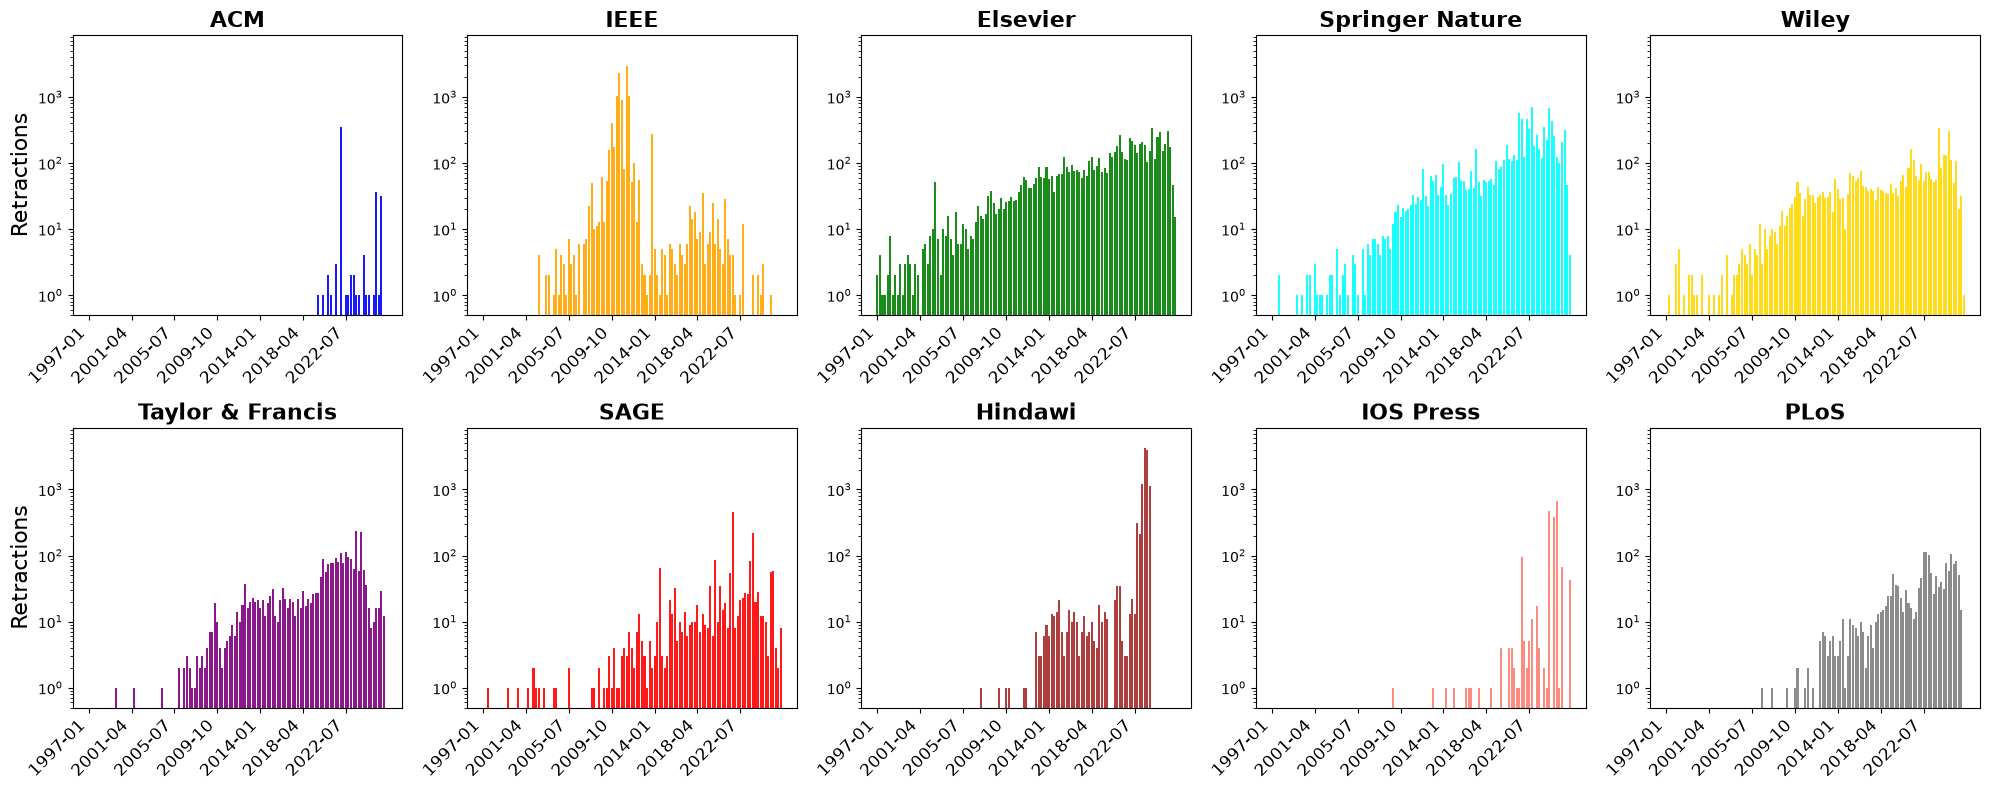

In [9]:
plot_small_multiples(df, freq='Q', log_scale=True,
                      output_file='entries-per-quarter-log-nonoverlap.eps')

In [10]:
# Code converted from Matplotlib to Plotly by Claude, with some minor modifications by Miquel Perello Nieto

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np


def plot_small_multiples_plotly(df, freq, log_scale, output_file, figsize=(20, 8)):
    """Plot a 2x5 grid of bar charts, one per publisher.

    Parameters
    ----------
    df         : DataFrame with 'Publisher' and 'RetractionDate' columns.
    freq       : 'M' for monthly, 'Q' for quarterly.
    log_scale  : bool — use logarithmic y-axis.
    output_file: str — path for the saved PDF/PNG figure (extension determines format).
    figsize    : tuple — (width, height) in inches; converted to pixels at 96 dpi.
    """
    # ------------------------------------------------------------------
    # 1. Compute period counts per publisher and determine global date range
    # ------------------------------------------------------------------
    period_counts = {}
    all_min, all_max = None, None

    for label, rw_names in PUBLISHERS.items():
        pub_df = df[df["Publisher"].isin(rw_names)]
        counts = (
            pub_df["RetractionDate"]
            .dt.to_period(freq)
            .value_counts()
            .sort_index()
        )
        period_counts[label] = counts
        if len(counts) > 0:
            pmin, pmax = counts.index.min(), counts.index.max()
            all_min = pmin if all_min is None else min(all_min, pmin)
            all_max = pmax if all_max is None else max(all_max, pmax)

    # Enforce start date of 1997 (ACM-DL launched October 1997)
    start_date = pd.Period("1997-01", freq=freq)
    if all_max < start_date:
        print("Warning: Data ends before 1997 start date.")
        return

    full_range = pd.period_range(start=start_date, end=all_max, freq=freq)

    # Reindex all publishers to the shared range
    for label in period_counts:
        period_counts[label] = period_counts[label].reindex(full_range, fill_value=0)

    global_ymax = max(s.max() for s in period_counts.values())

    # ------------------------------------------------------------------
    # 2. Build subplot grid
    # ------------------------------------------------------------------
    ncols, nrows = 5, 2
    publisher_items = list(period_counts.items())
    n_publishers = len(publisher_items)

    # subplot_titles pads empty strings for unused cells so titles align
    subplot_titles = [label for label, _ in publisher_items]
    subplot_titles += [""] * (nrows * ncols - n_publishers)

    fig = make_subplots(
        rows=nrows,
        cols=ncols,
        subplot_titles=subplot_titles,
        horizontal_spacing=0.06,
        vertical_spacing=0.18,
    )

    # ------------------------------------------------------------------
    # 3. Add one Bar trace per publisher
    # ------------------------------------------------------------------
    x_indices = list(range(len(full_range)))

    # Target ~7 tick labels regardless of dataset length
    total_bars = len(full_range)
    step = max(1, total_bars // 7)
    tick_positions = list(range(0, total_bars, step))
    tick_labels = [full_range[i].start_time.strftime("%Y-%m") for i in tick_positions]

    for idx, (label, counts) in enumerate(publisher_items):
        row, col = divmod(idx, ncols)
        row += 1   # Plotly rows are 1-indexed
        col += 1

        fig.add_trace(
            go.Bar(
                x=x_indices,
                y=counts.values,
                marker_color=PUBLISHER_COLORS[label],
                marker_opacity=0.9,
                width=0.8,
                showlegend=False,
                name=label,
            ),
            row=row,
            col=col,
        )

        # Axis keys are 'xaxis', 'xaxis2', … for subplot (1,1), (1,2), …
        axis_suffix = "" if idx == 0 else str(idx + 1)
        xaxis_key = f"xaxis{axis_suffix}"
        yaxis_key = f"yaxis{axis_suffix}"

        fig.layout[xaxis_key].update(
            tickvals=tick_positions,
            ticktext=tick_labels,
            tickangle=45,
            tickfont=dict(size=TICK_FONTSIZE),
        )

        y_axis_update = dict(tickfont=dict(size=TICK_FONTSIZE))

        if log_scale:
            y_axis_update.update(
                type="log",
                range=[
                    -0.3,                          # log10(0.5) ≈ -0.3
                    np.log10(global_ymax * 2),  # headroom above max
                ],
            )
        else:
            y_axis_update.update(
                type="linear",
                range=[0, global_ymax * 1.05],
            )

        # Show y-axis label only on the leftmost column
        if col == 1:
            y_axis_update["title"] = dict(
                text="Retractions", font=dict(size=AXIS_FONTSIZE)
            )

        fig.layout[yaxis_key].update(**y_axis_update)

    # ------------------------------------------------------------------
    # 4. Global layout
    # ------------------------------------------------------------------
    width_px  = int(figsize[0] * 96)
    height_px = int(figsize[1] * 96)

    fig.update_layout(
        width=width_px,
        height=height_px,
        bargap=0.1,
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin=dict(l=50, r=20, t=60, b=60),
    )

    # Bold subplot titles (annotation objects created by make_subplots)
    for annotation in fig.layout.annotations:
        annotation.update(font=dict(size=AXIS_FONTSIZE, color="black"), font_weight="bold")

    # ------------------------------------------------------------------
    # 5. Save and show
    # ------------------------------------------------------------------
    # Plotly write_image supports: .pdf .svg .png .jpeg .webp
    # Replace .eps with .pdf in output_file if you were saving EPS before
    fig.write_image(output_file)
    print(f"Saved {output_file}")
    fig.show()

Saved entries-per-quarter-log-nonoverlap.svg


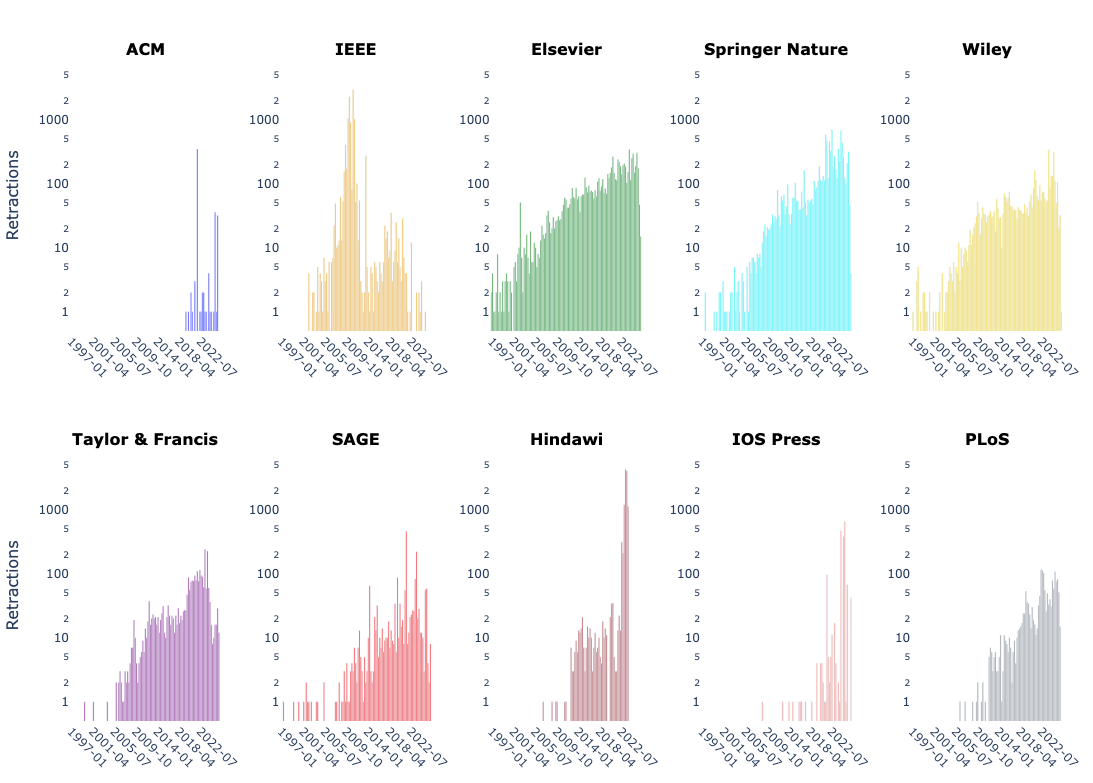

In [12]:
plot_small_multiples_plotly(df, freq='Q', log_scale=True,
                      output_file='entries-per-quarter-log-nonoverlap.svg')